In [348]:
import json
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from keras.layers import Dense,Dropout,SimpleRNN,LSTM #Biblioteca para deep learning
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold


In [349]:
# Carregar o arquivo JSON
with open('config_pso.json') as f:
    config = json.load(f)

In [350]:
base_path = './dataset/'
time_base = 'days'
agrupamento = "3"
dataset_type = f"{agrupamento}_days_dataset"

scaler = MinMaxScaler(feature_range=(0, 1))  # Padronização dos dados

duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_{agrupamento}_{time_base}.csv'
prataI_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_I_{agrupamento}_{time_base}.csv'
prataII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_II_{agrupamento}_{time_base}.csv'
prataIII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_III_{agrupamento}_{time_base}.csv'
pirapama_dataset = f'{base_path}outras_unidades/pirapama/Pirapama_{agrupamento}_{time_base}.csv'

In [351]:
# transformando CSV em DataFrame
duas_unas_df = pd.read_csv(duas_unas_dataset)  # Transformação em dataset
prataI_df = pd.read_csv(prataI_dataset)  # Transformação em dataset
prataII_df = pd.read_csv(prataII_dataset)  # Transformação em dataset
prataIII_df = pd.read_csv(prataIII_dataset)  # Transformação em dataset
pirapama_df = pd.read_csv(pirapama_dataset)  # Transformação em dataset

In [352]:
validation_interval = config['datasets'][dataset_type]['timesteps'] + config['datasets'][dataset_type]['output_horizon'] # Definição da parcela dos dados que serão retiradas do treinamento/teste para validação
#print(validation_interval)

indices_to_validate = duas_unas_df.index[-validation_interval:].tolist()  # Obtenção dos índices dos dadoss de validação

datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]  # df1, df2, etc., são os seus dataframes

# Aplicar MinMaxScaler para cada dataset individualmente
scaled_datasets = []
for i, df in enumerate(datasets):
    # Garantir que 'timestamp' é do tipo datetime e já está configurado corretamente como índice
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values(by='timestamp')
        df.set_index('timestamp', inplace=True)

    # Aplicar o scaler apenas nas colunas numéricas
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df.select_dtypes(include=[float, int]))  # Apenas colunas numéricas
    scaled_df = pd.DataFrame(scaled_data, columns=df.select_dtypes(include=[float, int]).columns, index=df.index)
    
    # Adicionar o DataFrame escalado à lista
    scaled_datasets.append(scaled_df)

# print(scaled_datasets[4].index)
# print(indices_to_validate)

# duas_unas_df_scaled = scaled_datasets[4].iloc[~scaled_datasets[4].index.isin(indices_to_validate)].reset_index(drop=True)
# print(duas_unas_df_scaled)
duas_unas_validation_scaled = scaled_datasets[4].tail(validation_interval)  # Criação do dataset de validação
#print(duas_unas_validation_scaled)
#duas_unas_df_scaled = scaled_datasets[4].drop(tail(indices_to_validate.shape)).reset_index(drop=True)  # Retirada dos dados de validação do dataset original de treino/teste

# Define o número de linhas a serem removidas
X = len(indices_to_validate)
duas_unas_df_scaled = scaled_datasets[4].iloc[:-X]
#print(duas_unas_df_scaled)
# print(duas_unas_validation_scaled)

scaled_datasets[4] = duas_unas_df_scaled

In [353]:
def identify_peaks_and_valleys(y_test):
    # Converte y_test em um tensor
    #y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    # Inicializa pesos como um tensor de 1s do mesmo formato
    weights = tf.ones(tf.shape(y_test), dtype=tf.float32)

    # Condicional para verificar se y_test tem pelo menos 3 elementos
    mask = tf.size(y_test) < 3

    # Função para processar picos e vales
    def process_peaks_and_valleys():
        # Certifique-se de que y_test é do tipo float32
        y_test_float = tf.cast(y_test, tf.float32)

        # Obtém os índices de picos e vales para elementos intermediários
        # Corrigido: use tf.expand_dims para garantir que o primeiro elemento tenha o formato correto
        y_test_prev = tf.concat([tf.expand_dims(y_test_float[0], axis=0), y_test_float[:-1]], axis=0)  # Adiciona o primeiro elemento como anterior
        y_test_next = tf.concat([y_test_float[1:], tf.expand_dims(y_test_float[-1], axis=0)], axis=0)  # Adiciona o último elemento como próximo

        # Define picos e vales para os elementos intermediários
        peaks = tf.where((y_test_float > y_test_prev) & (y_test_float > y_test_next))
        valleys = tf.where((y_test_float < y_test_prev) & (y_test_float < y_test_next))

        # Atualiza os pesos para picos e vales intermediários
        weights_updated = tf.tensor_scatter_nd_update(weights, peaks, tf.fill(tf.shape(peaks)[:1], 3.0))
        weights_updated = tf.tensor_scatter_nd_update(weights_updated, valleys, tf.fill(tf.shape(valleys)[:1], 3.0))

        return weights_updated

    # Condicional para executar a função de processamento se y_test tiver 3 ou mais elementos
    weights = tf.cond(mask, lambda: weights, process_peaks_and_valleys)

    return weights


In [354]:
# Função WMAE ajustada com pesos para picos e vales
def wmae(y_test, y_pred):
    # Convertendo y_test e y_pred para float32
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    #y_test = tf.squeeze(y_test)
    #y_pred = tf.squeeze(y_pred)

    weights = identify_peaks_and_valleys(y_test)

    return (tf.reduce_sum(weights * tf.abs(y_test - y_pred)) / tf.reduce_sum(weights))

In [355]:
def wmse(y_test, y_pred):
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    weights = identify_peaks_and_valleys(y_test)

    wmse_value = (tf.reduce_sum(weights * tf.square(y_test - y_pred)) / tf.reduce_sum(weights))

    return wmse_value

In [356]:
def create_model(config, dataset_type, X_train, X, y):
   
    n_folds = 5  # Número de folds

    # Instanciar KFold
    kf = KFold(n_splits=n_folds, shuffle=False)  # shuffle=False para manter a sequência temporal

    # Armazenar métricas de cada fold
    fold_metrics = []

    # Loop pelos folds
    for train_index, val_index in kf.split(X):
        # Dividir os dados em treinamento e validação
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
    
    model = Sequential()

    for _ in range(int(config['datasets'][dataset_type]['layers'])):
        model.add(LSTM(int(config['datasets'][dataset_type]['neurons']), return_sequences=True if _ < int(config['datasets'][dataset_type]["layers"]) - 1 else False, input_shape=(X_train.shape[1], 1)))

        model.add(Dropout(config['datasets'][dataset_type]['dropout']))

    model.add(Dense(config['datasets'][dataset_type]['output_horizon'], activation=config['datasets'][dataset_type]['activation']))

    model.summary()

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type]['optimizer']
    
    if optimizer == 'adam':
        opt = Adam(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    else:
        opt = SGD(learning_rate=config['datasets'][dataset_type]['learning_rate'])

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', patience=config['datasets'][dataset_type]['patience'], restore_best_weights=True)

    history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                        verbose=1, callbacks=[early_stopping])
    
    plt.plot(history.history['loss'], label='Loss de Treinamento')
    plt.plot(history.history['val_loss'], label='Loss de Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.show()

In [357]:
def create_dataset(data, time_step, output_steps):  # Função para construção do dataset
    X= []  # Criação das listas
    y = []
    for i in range(len(data) - time_step - output_steps + 1):  # Loop
        X.append(data.iloc[i:(i + time_step), 0])  # Construção do dataset com `.iloc`
        y.append(data.iloc[(i + time_step):(i + time_step + output_steps), 0])
    
    print("X shape", np.array(X).shape)
    print("y shape", np.array(y).shape)
    return np.array(X), np.array(y)

In [358]:
def concatenate_selected_datasets(datasets, indices):
    
    # Selecionar os datasets pelos índices fornecidos
    selected_datasets = [datasets[i] for i in indices]
    
    # Concatenar os datasets selecionados
    concatenated_df = pd.concat(selected_datasets, ignore_index=True)
    
    # Resetar o índice para uma sequência numérica
    concatenated_df.reset_index(drop=True, inplace=True)
    
    return concatenated_df

In [359]:
### DATASETS PARA TESTE 02 ###

indices = [1, 2, 3, 4]
dataset_test_2 = concatenate_selected_datasets(scaled_datasets, indices)

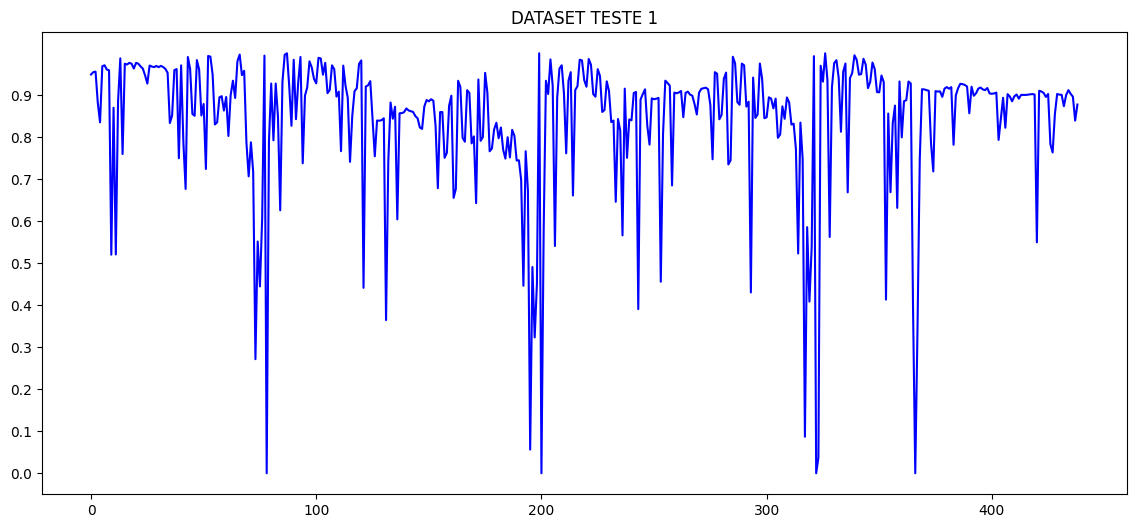

In [360]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_2, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [361]:
timesteps = config['datasets'][dataset_type]["timesteps"]
output_steps = config['datasets'][dataset_type]["output_horizon"]
X, y = create_dataset(dataset_test_2, timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("X_train shape", np.array(X_train).shape)
# print("y_train shape", np.array(y_train).shape)
# print("X_test shape", np.array(X_test).shape)
# print("y_test shape", np.array(y_test).shape)

X shape (409, 1)
y shape (409, 30)
X_train shape (327, 1, 1)
y_train shape (327, 30)
X_test shape (82, 1, 1)
y_test shape (82, 30)


In [ ]:
def evaluate_model_with_cross_validation(data, time_step, output_steps):
    tscv = TimeSeriesSplit(n_splits=5)  # Defina o número de splits
    scores = []

    for train_index, test_index in tscv.split(data):
        train_data, test_data = data.iloc[train_index], data.iloc[test_index]
        
        # Criação do dataset
        X_train, y_train = create_dataset(train_data, time_step, output_steps)
        X_test, y_test = create_dataset(test_data, time_step, output_steps)
    
        # Reshape para LSTM [samples, time steps, features]
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

        # Criação do modelo
        model = build_lstm_model((X_train.shape[1], 1))

        # Early stopping
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        # Treinamento do modelo
        model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), 
                  callbacks=[early_stopping], verbose=0)

        # Avaliação do modelo
        score = model.evaluate(X_test, y_test, verbose=0)
        scores.append(score)

    return scores

c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_75 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_76 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_77 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.7139 - val_loss: 0.1458
Epoch 2/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1848 - val_loss: 0.1125
Epoch 3/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1667 - val_loss: 0.1237
Epoch 4/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1651 - val_loss: 0.1094
Epoch 5/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1511 - val_loss: 0.1229
Epoch 6/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1440 - val_loss: 0.1095
Epoch 7/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1442 - val_loss: 0.1105
Epoch 8/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1380 - val_loss: 0.1274
Epoch 9/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1387 - val_loss: 0.1083
Epoch 10/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1398 - val_loss: 0.1277
Epoch 11/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1251 - val_loss: 0.1193
Epoch 12/100000
22/22 ━━━━━━━

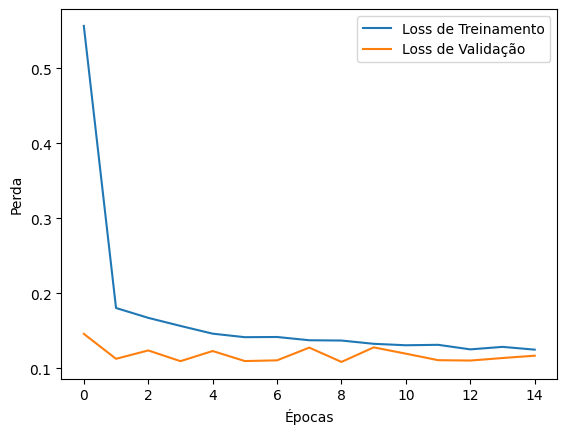

In [362]:
create_model(config, dataset_type, X, y)